# ML Model Selection

Three supervised classifiers are trained and compared: **Decision Tree**, **Random Forest**, and **Logistic Regression**.  
Evaluation uses Precision, Recall, and F1-Score — accuracy alone is misleading on an imbalanced dataset.


## Setup


In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

X_train_s   = np.load("../data/X_train.npy")
X_val_s     = np.load("../data/X_val.npy")
X_test_s    = np.load("../data/X_test.npy")
y_train     = np.load("../data/y_train.npy")
y_val       = np.load("../data/y_val.npy")
y_test      = np.load("../data/y_test.npy")
X_train_enc = pd.read_csv("../data/X_train_enc.csv")
scaler      = joblib.load("../data/scaler.pkl")
feature_names = X_train_enc.columns.tolist()

print("Successfully loaded data.")

Successfully loaded data.


## Model 1 — Decision Tree


### Grid Search — Decision Tree


In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score

scoring = {
    'f1_minority': make_scorer(f1_score, pos_label=0),
    'balanced_accuracy': make_scorer(balanced_accuracy_score)
}

dt_param_grid = {
    "class_weight":      [{0:2, 1:1}, {0:3, 1:1}],
    "criterion":         ["gini", "entropy"],
    "max_depth":         [5, 10, 15, 20],
    "min_samples_split": [20, 40, 60],
    "min_samples_leaf":  [10, 20, 30],
}

dt_gs = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring=scoring,
    refit='f1_minority',
    cv=5,
    n_jobs=-1,
    verbose=1,
)
dt_gs.fit(X_train_s, y_train)
print("Best params:", dt_gs.best_params_)
print("Best F1 (minority):", dt_gs.cv_results_['mean_test_f1_minority'][dt_gs.best_index_])
print("Best Balanced Accuracy:", dt_gs.cv_results_['mean_test_balanced_accuracy'][dt_gs.best_index_])

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'class_weight': {0: 2, 1: 1}, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 60}
Best F1 (minority): 0.8292108273112879
Best Balanced Accuracy: 0.8889828684981271


In [4]:
dt = dt_gs.best_estimator_

print("Decision Tree — Validation Set")
print(classification_report(y_val, dt.predict(X_val_s), target_names=["Not Shortlisted", "Shortlisted"]))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_val, dt.predict(X_val_s)), 4))

Decision Tree — Validation Set
                 precision    recall  f1-score   support

Not Shortlisted       0.76      0.88      0.82      1355
    Shortlisted       0.95      0.88      0.91      3145

       accuracy                           0.88      4500
      macro avg       0.85      0.88      0.87      4500
   weighted avg       0.89      0.88      0.88      4500

Balanced Accuracy: 0.8819


## Model 2 — Random Forest


### Grid Search — Random Forest


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "class_weight":      [{0:2, 1:1}, {0:3, 1:1}],
    "n_estimators":      [100, 200, 300],
    "max_depth":         [10, 15, 20],
    "min_samples_split": [10, 20, 40],
}

rf_gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring=scoring,
    refit='f1_minority',
    cv=5,
    n_jobs=-1,
    verbose=1,
)
rf_gs.fit(X_train_s, y_train)
print("Best params:", rf_gs.best_params_)
print("Best F1 (minority):", rf_gs.cv_results_['mean_test_f1_minority'][rf_gs.best_index_])
print("Best Balanced Accuracy:", rf_gs.cv_results_['mean_test_balanced_accuracy'][rf_gs.best_index_])

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'class_weight': {0: 2, 1: 1}, 'max_depth': 10, 'min_samples_split': 20, 'n_estimators': 200}
Best F1 (minority): 0.8473890824431575
Best Balanced Accuracy: 0.900140281866977


In [6]:
rf = rf_gs.best_estimator_

print("Random Forest — Validation Set")
print(classification_report(y_val, rf.predict(X_val_s), target_names=["Not Shortlisted", "Shortlisted"]))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_val, rf.predict(X_val_s)), 4))

Random Forest — Validation Set
                 precision    recall  f1-score   support

Not Shortlisted       0.80      0.89      0.84      1355
    Shortlisted       0.95      0.90      0.93      3145

       accuracy                           0.90      4500
      macro avg       0.87      0.89      0.88      4500
   weighted avg       0.90      0.90      0.90      4500

Balanced Accuracy: 0.8948


## Model 3 — Logistic Regression


### Grid Search — Logistic Regression


In [7]:
from sklearn.linear_model import LogisticRegression

lr_param_grid = {
    "class_weight": [{0:2, 1:1}, {0:3, 1:1}],
    "C":      [0.01, 0.1, 1.0, 10.0, 100.0],
    "solver": ["lbfgs", "liblinear"],
}

lr_gs = GridSearchCV(
    estimator=LogisticRegression(max_iter=500, random_state=42),
    param_grid=lr_param_grid,
    scoring=scoring,
    refit='f1_minority',
    cv=5,
    n_jobs=-1,
    verbose=1,
)
lr_gs.fit(X_train_s, y_train)
print("Best params:", lr_gs.best_params_)
print("Best F1 (minority):", lr_gs.cv_results_['mean_test_f1_minority'][lr_gs.best_index_])
print("Best Balanced Accuracy:", lr_gs.cv_results_['mean_test_balanced_accuracy'][lr_gs.best_index_])

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'C': 1.0, 'class_weight': {0: 2, 1: 1}, 'solver': 'lbfgs'}
Best F1 (minority): 0.8446526888255713
Best Balanced Accuracy: 0.9017015030230915


In [8]:
lr = lr_gs.best_estimator_

print("Logistic Regression — Validation Set")
print(classification_report(y_val, lr.predict(X_val_s), target_names=["Not Shortlisted", "Shortlisted"]))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_val, lr.predict(X_val_s)), 4))

Logistic Regression — Validation Set
                 precision    recall  f1-score   support

Not Shortlisted       0.78      0.90      0.83      1355
    Shortlisted       0.95      0.89      0.92      3145

       accuracy                           0.89      4500
      macro avg       0.87      0.89      0.88      4500
   weighted avg       0.90      0.89      0.89      4500

Balanced Accuracy: 0.8948


## Validation Comparison


In [9]:
models = {"Decision Tree": dt, "Random Forest": rf, "Logistic Regression": lr}

rows = []
for name, model in models.items():
    preds = model.predict(X_val_s)
    rows.append({
        "Model": name,
        "Precision": round(precision_score(y_val, preds, zero_division=0), 4),
        "Recall":    round(recall_score(y_val, preds), 4),
        "F1-Score":  round(f1_score(y_val, preds), 4),
        "Accuracy":  round((preds == y_val).mean(), 4)
    })

comparison = pd.DataFrame(rows).set_index("Model")
comparison

,Precision,Recall,F1-Score,Accuracy
Model,,,,
Decision Tree,0.9452,0.8827,0.9129,0.8822
Random Forest,0.9486,0.9033,0.9254,0.8982
Logistic Regression,0.9537,0.8900,0.9207,0.8929


## Final Test Set Evaluation


In [10]:
print("Random Forest — Test Set")
print(classification_report(y_test, rf.predict(X_test_s), target_names=["Not Shortlisted", "Shortlisted"]))

print("Logistic Regression — Test Set")
print(classification_report(y_test, lr.predict(X_test_s), target_names=["Not Shortlisted", "Shortlisted"]))

Random Forest — Test Set
                 precision    recall  f1-score   support

Not Shortlisted       0.81      0.89      0.85      1355
    Shortlisted       0.95      0.91      0.93      3145

       accuracy                           0.90      4500
      macro avg       0.88      0.90      0.89      4500
   weighted avg       0.91      0.90      0.91      4500

Logistic Regression — Test Set
                 precision    recall  f1-score   support

Not Shortlisted       0.79      0.90      0.84      1355
    Shortlisted       0.95      0.90      0.93      3145

       accuracy                           0.90      4500
      macro avg       0.87      0.90      0.88      4500
   weighted avg       0.91      0.90      0.90      4500



## Feature Importance

Random Forest feature importances rank how much each feature contributed to predictions.  
Used to generate targeted improvement feedback for rejected candidates.


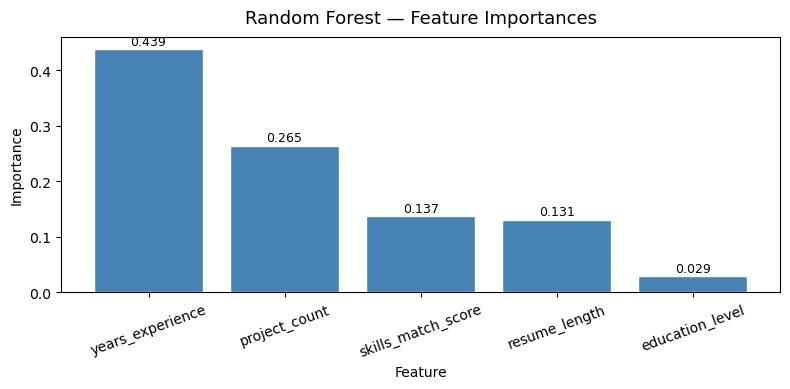

Feature importances:
  years_experience          0.4386
  project_count             0.2645
  skills_match_score        0.1371
  resume_length             0.1310
  education_level           0.0288


In [11]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sorted_features, sorted_importances, color="steelblue", edgecolor="white")
ax.set_title("Random Forest — Feature Importances", fontsize=13, pad=10)
ax.set_ylabel("Importance")
ax.set_xlabel("Feature")
ax.tick_params(axis="x", rotation=20)
for bar, val in zip(bars, sorted_importances):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("Feature importances:")
for f, imp in zip(sorted_features, sorted_importances):
    print(f"  {f:<25} {imp:.4f}")

## Feedback Generation

For a candidate predicted as _Not Shortlisted_, their feature values are compared against the median benchmarks of shortlisted candidates in the training set, sorted by feature importance.


In [12]:
benchmarks = X_train_enc[y_train == 1].median()
edu_labels = {0: "High School", 1: "Bachelors", 2: "Masters", 3: "PhD"}

def generate_feedback(candidate: dict) -> str:
    """
    candidate: dict with keys matching feature_names.
    education_level should be provided as int (0=High School, 1=Bachelors, 2=Masters, 3=PhD).
    """
    row = pd.DataFrame([candidate])[feature_names]
    row_scaled = scaler.transform(row)
    pred = rf.predict(row_scaled)[0]

    if pred == 1:
        return "Strong profile — predicted to be shortlisted."

    importance_map = dict(zip(feature_names, rf.feature_importances_))
    lines = ["Profile is below the shortlisted threshold. Suggested improvements:\n"]
    for feat in sorted(feature_names, key=lambda f: importance_map[f], reverse=True):
        val = candidate[feat]
        bench = benchmarks[feat]
        if val < bench:
            if feat == "education_level":
                lines.append(f"  - education_level: {edu_labels.get(int(val))} -> consider {edu_labels.get(int(bench))}")
            else:
                lines.append(f"  - {feat}: {val} (benchmark: {bench:.1f})")
    return "\n".join(lines)


sample = {
    "years_experience":   2,
    "skills_match_score": 55.0,
    "education_level":    1,
    "project_count":      3,
    "resume_length":      300
}
print(generate_feedback(sample))

Profile is below the shortlisted threshold. Suggested improvements:

  - years_experience: 2 (benchmark: 10.0)
  - project_count: 3 (benchmark: 12.0)
  - skills_match_score: 55.0 (benchmark: 80.1)
  - resume_length: 300 (benchmark: 640.0)
  - education_level: Bachelors -> consider Masters
